# YOLO11-S + DCT + AG × 2 — Confidence Threshold Sweep
**Architecture:** YOLO11-S with MultiSpectralAttention (DCT) @ L10 and two AttentionGates on FPN skips (L13 P4, L17 P3)  
**Datasets:** D-Fire + NEMO + PyroNear (pyro-sdis) → unified corpus of ~55,698 images  
**Hardware:** Kaggle T4 | **Framework:** Ultralytics YOLO11, PyTorch  
**Objective:** Find the optimal confidence threshold trading FP-rate vs recall across all three evaluation sets.

**Notebook structure:**
1. Setup
2–6. Dataset pipeline (D-Fire, NEMO, PyroNear → Unified)
7–8. Module definitions + Ultralytics registration  
9. Architecture YAML + verification  
10. Load saved model  
11. Pre-sweep validation — Eval C (PyroNear, conf=0.25)  
12. Sweep configuration  
13. Single-pass detection cache  
14. Threshold sweep  
15. Results table + CSV  
16. Visualisations (PR curves, FPR/Recall tradeoff)  
17. Spatial prior analysis (bonus: sky-zone FP filtering)


---
## 1. Setup

In [2]:
!pip install ultralytics pycocotools datasets matplotlib opencv-python-headless -q

import os, gc, json, shutil, random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from PIL import Image
import cv2

print(f"Torch       : {torch.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")
print(f"Device      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print("Libraries loaded ✅")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.6 MB/s eta 0:00:00
Torch       : 2.10.0+cu128
CUDA        : True
Device      : Tesla T4
Libraries loaded ✅


---
## 2. D-Fire — Load, Filter & Verify

**Source:** `github.com/gaia-solutions-on-demand/DFireDataset` (Kaggle: `sayedgamal99/smoke-fire-detection-yolo`)  
**Size:** 21,527 RGB images — filtered to ~18,700 by rejecting close-up shots (box area > 40%)  
**Classes:** 0=smoke, 1=fire  
**Hard negatives:** ~9,838 images of lamp/sun glare, environmental confusion


In [3]:
DFIRE_PATH  = "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data"
CLASS_NAMES = ["smoke", "fire"]
COLORS      = [(0.39, 0.71, 1.0), (1.0, 0.31, 0.0)]

for split in ["train", "val", "test"]:
    img_dir = Path(DFIRE_PATH) / split / "images"
    lbl_dir = Path(DFIRE_PATH) / split / "labels"
    if img_dir.exists():
        imgs = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
        lbls = list(lbl_dir.glob("*.txt"))
        print(f"D-Fire {split:5s}: {len(imgs):6d} images | {len(lbls):6d} labels")
    else:
        print(f"D-Fire {split}: path not found")


D-Fire train:  14122 images |  14122 labels
D-Fire val  :   3099 images |   3099 labels
D-Fire test :   4306 images |   4306 labels


In [4]:
def is_distant_shot(label_path, max_box_area=0.40):
    lbl = Path(label_path)
    if not lbl.exists():
        return True
    with open(lbl) as f:
        lines = f.readlines()
    if not lines or all(l.strip() == '' for l in lines):
        return True
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        _, xc, yc, bw, bh = map(float, parts)
        if bw * bh > max_box_area:
            return False
    return True


print("Filtering D-Fire (max box area = 40%)...")
dfire_kept     = {}
dfire_rejected = {}

for split in ["train", "val", "test"]:
    img_dir = Path(DFIRE_PATH) / split / "images"
    lbl_dir = Path(DFIRE_PATH) / split / "labels"
    kept, rejected = [], []
    for img_path in sorted(img_dir.glob("*.jpg")):
        lbl_path = lbl_dir / f"{img_path.stem}.txt"
        if is_distant_shot(lbl_path):
            kept.append(img_path)
        else:
            rejected.append(img_path)
    dfire_kept[split]     = kept
    dfire_rejected[split] = rejected
    pct = len(rejected) / max(len(kept) + len(rejected), 1) * 100
    print(f"  {split:5s}: kept {len(kept):6d} | rejected {len(rejected):5d} ({pct:.1f}% removed)")

total_kept     = sum(len(v) for v in dfire_kept.values())
total_rejected = sum(len(v) for v in dfire_rejected.values())
print(f"\nTotal kept: {total_kept} | rejected: {total_rejected} "
      f"({total_rejected/(total_kept+total_rejected)*100:.1f}% overall)")


Filtering D-Fire (max box area = 40%)...
  train: kept  12270 | rejected  1852 (13.1% removed)
  val  : kept   2676 | rejected   423 (13.6% removed)
  test : kept   3754 | rejected   552 (12.8% removed)

Total kept: 18700 | rejected: 2827 (13.1% overall)


---
## 3. NEMO — Convert COCO JSON → YOLO

**Source:** `github.com/SayBender/Nemo` (Kaggle: `werus23/nevada-smoke-detection-data`)  
**Size:** 2,934 images, 4,522 labeled smoke bounding boxes  
**Classes:** Smoke only (all densities → class 0)


In [5]:
NEMO_BASE       = "/kaggle/input/datasets/werus23/nevada-smoke-detection-data"
NEMO_TRAIN_IMGS = f"{NEMO_BASE}/NEMO data/train_images"
NEMO_VAL_IMGS   = f"{NEMO_BASE}/NEMO data/val_images"
NEMO_TRAIN_JSON = f"{NEMO_BASE}/NEMO data/annotation_train.json"
NEMO_VAL_JSON   = f"{NEMO_BASE}/NEMO data/annotation_val.json"
NEMO_2023_IMGS  = f"{NEMO_BASE}/20-23_daytime_images/daytime images"
NEMO_2023_JSON  = f"{NEMO_BASE}/20-23_daytime_label.json"


def coco_to_yolo(json_path, img_src_dir, img_dst_dir, lbl_dst_dir, smoke_class=0):
    os.makedirs(img_dst_dir, exist_ok=True)
    os.makedirs(lbl_dst_dir, exist_ok=True)
    with open(json_path) as f:
        coco = json.load(f)
    img_map = {img["id"]: img for img in coco["images"]}
    ann_map = {}
    for ann in coco["annotations"]:
        ann_map.setdefault(ann["image_id"], []).append(ann)
    converted = copied = 0
    for img_id, img_info in img_map.items():
        W, H   = img_info["width"], img_info["height"]
        fname  = Path(img_info["file_name"]).stem
        src    = Path(img_src_dir) / Path(img_info["file_name"]).name
        if src.exists():
            shutil.copy2(src, Path(img_dst_dir) / src.name)
            copied += 1
        lines = []
        for ann in ann_map.get(img_id, []):
            x, y, w, h = ann["bbox"]
            xc, yc = (x + w/2)/W, (y + h/2)/H
            wn, hn = w/W, h/H
            lines.append(f"{smoke_class} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}")
        with open(Path(lbl_dst_dir) / f"{fname}.txt", "w") as f:
            f.write("\n".join(lines))
        converted += 1
    print(f"  Converted {converted} labels, copied {copied} images")


print("Converting NEMO train...")
coco_to_yolo(NEMO_TRAIN_JSON, NEMO_TRAIN_IMGS,
             "/kaggle/working/nemo_yolo/images/train",
             "/kaggle/working/nemo_yolo/labels/train")
print("Converting NEMO val...")
coco_to_yolo(NEMO_VAL_JSON, NEMO_VAL_IMGS,
             "/kaggle/working/nemo_yolo/images/val",
             "/kaggle/working/nemo_yolo/labels/val")
print("Merging 20-23 daytime into train...")
coco_to_yolo(NEMO_2023_JSON, NEMO_2023_IMGS,
             "/kaggle/working/nemo_yolo/images/train",
             "/kaggle/working/nemo_yolo/labels/train")

print("\nNEMO conversion complete:")
for split in ["train", "val"]:
    imgs = list(Path(f"/kaggle/working/nemo_yolo/images/{split}").glob("*.jpg"))
    lbls = list(Path(f"/kaggle/working/nemo_yolo/labels/{split}").glob("*.txt"))
    print(f"  {split}: {len(imgs)} images | {len(lbls)} labels")


Converting NEMO train...
  Converted 2680 labels, copied 2680 images
Converting NEMO val...
  Converted 250 labels, copied 250 images
Merging 20-23 daytime into train...
  Converted 432 labels, copied 432 images

NEMO conversion complete:
  train: 3112 images | 3112 labels
  val: 250 images | 250 labels


---
## 4. PyroNear (pyro-sdis) — Load from HuggingFace & Convert to YOLO

**Source:** `pyronear/pyro-sdis` on HuggingFace (public)  
**Size:** 33,636 images | Smoke only (class 0) | ~16% hard negatives  
**Camera setup:** Fixed outdoor SDIS French fire brigade tower cameras


In [6]:
from datasets import load_dataset
from kaggle_secrets import UserSecretsClient

os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")

print("Loading PyroNear dataset...")
ds = load_dataset("pyronear/pyro-sdis")
print(f"Train samples : {len(ds['train'])}")
print(f"Val samples   : {len(ds['val'])}")

for split_name, split in [("Train", ds["train"]), ("Val", ds["val"])]:
    has_smoke = sum(1 for s in split if s["annotations"] and s["annotations"].strip())
    no_smoke  = len(split) - has_smoke
    print(f"\n{split_name}:")
    print(f"  Smoke positives  : {has_smoke}")
    print(f"  Hard negatives   : {no_smoke} ({no_smoke/len(split):.1%})")


Loading PyroNear dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00006.parquet:   0%|          | 0.00/481M [00:00<?, ?B/s]

data/train-00001-of-00006.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/train-00002-of-00006.parquet:   0%|          | 0.00/482M [00:00<?, ?B/s]

...

data/train-00005-of-00006.parquet:   0%|          | 0.00/483M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/390M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/29537 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/4099 [00:00<?, ? examples/s]

Train samples : 29537
Val samples   : 4099

Train:
  Smoke positives  : 24792
  Hard negatives   : 4745 (16.1%)

Val:
  Smoke positives  : 3345
  Hard negatives   : 754 (18.4%)


In [7]:
PYRO_DIRS = {
    "train_imgs": "/kaggle/working/pyro_yolo/images/train",
    "val_imgs":   "/kaggle/working/pyro_yolo/images/val",
    "train_lbls": "/kaggle/working/pyro_yolo/labels/train",
    "val_lbls":   "/kaggle/working/pyro_yolo/labels/val",
}
for d in PYRO_DIRS.values():
    os.makedirs(d, exist_ok=True)


def save_pyro_split(split, img_dir, lbl_dir, split_name):
    for i, sample in enumerate(split):
        img_name = Path(sample["image_name"]).stem
        sample["image"].save(str(Path(img_dir) / f"{img_name}.jpg"))
        ann = sample["annotations"]
        with open(Path(lbl_dir) / f"{img_name}.txt", "w") as f:
            if ann and ann.strip():
                lines = []
                for line in ann.strip().split("\n"):
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, cx, cy, bw, bh = parts
                        lines.append(f"0 {cx} {cy} {bw} {bh}")
                f.write("\n".join(lines))
        if (i + 1) % 5000 == 0:
            print(f"  {split_name}: {i+1} saved...")
    print(f"  {split_name} done: {len(split)} images")


print("Converting PyroNear train...")
save_pyro_split(ds["train"], PYRO_DIRS["train_imgs"], PYRO_DIRS["train_lbls"], "train")
print("Converting PyroNear val...")
save_pyro_split(ds["val"], PYRO_DIRS["val_imgs"], PYRO_DIRS["val_lbls"], "val")


Converting PyroNear train...
  train: 5000 saved...
  train: 10000 saved...
  train: 15000 saved...
  train: 20000 saved...
  train: 25000 saved...
  train done: 29537 images
Converting PyroNear val...
  val done: 4099 images


---
## 5. Merge → Unified YOLO Dataset

In [8]:
UNIFIED = "/kaggle/working/unified_dataset"

for split in ["train", "val", "test"]:
    Path(f"{UNIFIED}/images/{split}").mkdir(parents=True, exist_ok=True)
    Path(f"{UNIFIED}/labels/{split}").mkdir(parents=True, exist_ok=True)

print("Copying D-Fire (filtered)...")
for split in ["train", "val", "test"]:
    for img_path in dfire_kept[split]:
        shutil.copy2(img_path, f"{UNIFIED}/images/{split}/dfire_{img_path.name}")
        lbl = Path(f"{DFIRE_PATH}/{split}/labels") / f"{img_path.stem}.txt"
        if lbl.exists():
            shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/dfire_{lbl.name}")
print("  D-Fire ✅")

print("Copying NEMO...")
for split in ["train", "val"]:
    for img in Path(f"/kaggle/working/nemo_yolo/images/{split}").glob("*.jpg"):
        shutil.copy2(img, f"{UNIFIED}/images/{split}/nemo_{img.name}")
    for lbl in Path(f"/kaggle/working/nemo_yolo/labels/{split}").glob("*.txt"):
        shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/nemo_{lbl.name}")
print("  NEMO ✅")

print("Copying PyroNear...")
for split in ["train", "val"]:
    for img in Path(f"/kaggle/working/pyro_yolo/images/{split}").glob("*.jpg"):
        shutil.copy2(img, f"{UNIFIED}/images/{split}/pyro_{img.name}")
    for lbl in Path(f"/kaggle/working/pyro_yolo/labels/{split}").glob("*.txt"):
        shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/pyro_{lbl.name}")
print("  PyroNear ✅")

print("\n── Unified Dataset ──────────────────────────────")
total = 0
for split in ["train", "val", "test"]:
    imgs = list(Path(f"{UNIFIED}/images/{split}").glob("*.jpg"))
    lbls = list(Path(f"{UNIFIED}/labels/{split}").glob("*.txt"))
    pos  = sum(1 for l in lbls if l.read_text().strip())
    neg  = len(lbls) - pos
    print(f"  {split:5s}: {len(imgs):6d} images | "
          f"{pos:6d} positive | {neg:5d} negative ({neg/max(len(lbls),1):.1%})")
    total += len(imgs)
print(f"  TOTAL: {total} images")

print("\n── Source Breakdown ────────────────────────────")
for split in ["train", "val"]:
    dfire = len(list(Path(f"{UNIFIED}/images/{split}").glob("dfire_*")))
    nemo  = len(list(Path(f"{UNIFIED}/images/{split}").glob("nemo_*")))
    pyro  = len(list(Path(f"{UNIFIED}/images/{split}").glob("pyro_*")))
    print(f"  {split}: D-Fire={dfire} | NEMO={nemo} | PyroNear={pyro}")


Copying D-Fire (filtered)...
  D-Fire ✅
Copying NEMO...
  NEMO ✅
Copying PyroNear...
  PyroNear ✅

── Unified Dataset ──────────────────────────────
  train:  44919 images |  33716 positive | 11203 negative (24.9%)
  val  :   7025 images |   4896 positive |  2129 negative (30.3%)
  test :   3754 images |   1749 positive |  2005 negative (53.4%)
  TOTAL: 55698 images

── Source Breakdown ────────────────────────────
  train: D-Fire=12270 | NEMO=3112 | PyroNear=29537
  val: D-Fire=2676 | NEMO=250 | PyroNear=4099


---
## 6. Data YAML + Dataset Integrity Check

In [9]:
yaml_content = """# Unified Fire & Smoke Detection Dataset
# Sources: D-Fire (CC0) + NEMO (open source) + PyroNear/pyro-sdis (Apache 2.0)
# Total: ~55,698 images -- train: 44,919 | val: 7,025 | test: 3,754

path: /kaggle/working/unified_dataset
train: images/train
val:   images/val
test:  images/test

nc: 2
names:
  0: smoke
  1: fire
"""

DATA_YAML = "/kaggle/working/data.yaml"
with open(DATA_YAML, "w") as f:
    f.write(yaml_content.strip())
print(yaml_content)


# Unified Fire & Smoke Detection Dataset
# Sources: D-Fire (CC0) + NEMO (open source) + PyroNear/pyro-sdis (Apache 2.0)
# Total: ~55,698 images -- train: 44,919 | val: 7,025 | test: 3,754

path: /kaggle/working/unified_dataset
train: images/train
val:   images/val
test:  images/test

nc: 2
names:
  0: smoke
  1: fire



In [10]:
print("── Dataset Integrity Check ────────────────────────────────────")
for split in ["train", "val", "test"]:
    img_dir = Path(f"{UNIFIED}/images/{split}")
    lbl_dir = Path(f"{UNIFIED}/labels/{split}")
    imgs = {p.stem for p in img_dir.glob("*.jpg")}
    lbls = {p.stem for p in lbl_dir.glob("*.txt")}
    print(f"\n  {split.upper()}")
    print(f"    Images         : {len(imgs)}")
    print(f"    Labels         : {len(lbls)}")
    print(f"    Matched pairs  : {len(imgs & lbls)}")
    imgs_no_lbl = imgs - lbls
    lbls_no_img = lbls - imgs
    if imgs_no_lbl: print(f"    ⚠️  Images w/o label: {len(imgs_no_lbl)}")
    if lbls_no_img: print(f"    ⚠️  Labels w/o image: {len(lbls_no_img)}")
    for prefix in ["dfire", "nemo", "pyro"]:
        n_i = len(list(img_dir.glob(f"{prefix}_*.jpg")))
        n_l = len(list(lbl_dir.glob(f"{prefix}_*.txt")))
        mark = "✅" if n_i == n_l else "⚠️"
        print(f"    {mark} {prefix:8s}: {n_i} imgs | {n_l} lbls")


── Dataset Integrity Check ────────────────────────────────────

  TRAIN
    Images         : 44919
    Labels         : 44919
    Matched pairs  : 44919
    ✅ dfire   : 12270 imgs | 12270 lbls
    ✅ nemo    : 3112 imgs | 3112 lbls
    ✅ pyro    : 29537 imgs | 29537 lbls

  VAL
    Images         : 7025
    Labels         : 7025
    Matched pairs  : 7025
    ✅ dfire   : 2676 imgs | 2676 lbls
    ✅ nemo    : 250 imgs | 250 lbls
    ✅ pyro    : 4099 imgs | 4099 lbls

  TEST
    Images         : 3754
    Labels         : 3754
    Matched pairs  : 3754
    ✅ dfire   : 3754 imgs | 3754 lbls
    ✅ nemo    : 0 imgs | 0 lbls
    ✅ pyro    : 0 imgs | 0 lbls


---
## 7. Module Definitions

Two modules — orthogonal mechanisms, zero structural overlap:

| Module | Mechanism | Insertion | Role |
|--------|-----------|-----------|------|
| `MultiSpectralAttention` | Fixed DCT filter bank + channel MLP | L10, after SPPF | Frequency-aware recalibration before C2PSA |
| `AttentionGate` × 2 | Gated skip connections (Oktay 2018) | L13 (P4 skip), L17 (P3 skip) | Suppress haze texture before skip enters Concat |

> **Why this section is here:** `YOLO(best.pt)` must be called *after* these classes are in scope  
> and registered into Ultralytics' runtime (Section 8). If the classes are absent when the  
> checkpoint loads, Ultralytics throws or silently remaps layers — which was the root cause  
> of the broken-notebook validation failures.

### 7a. MultiSpectralAttention (DCT Frequency Attention)

**Reference:** FcaNet — Qin et al., ICCV 2021 — https://arxiv.org/abs/2012.11879  
**Insertion:** L10 — between SPPF (L9) and C2PSA (L11) | **Channels:** 512ch actual (gw=0.50) | **Spatial:** 20×20


In [11]:
class MultiSpectralAttention(nn.Module):
    """
    DCT-based channel attention — FcaNet (Qin et al., ICCV 2021).
    https://arxiv.org/abs/2012.11879

    Placed at L10 — after SPPF, before C2PSA.
    Channels: 512ch actual (gw=0.50). Spatial: 20×20 at 640 input (640/32).

    Smoke plumes carry mid-to-high frequency edges and irregular boundaries.
    Atmospheric haze/fog: low-frequency, spatially uniform activations.
    The DCT filter bank + MLP learns to distinguish these at the most
    compressed, globally-aware feature map before neck fan-out.

    Fixed DCT buffer (not learned). MLP attention weights are learned.
    Input/output: same shape (B, C, H, W) — drop-in replacement.
    """
    def __init__(self, channels, dct_h=20, dct_w=20, reduction=16):
        super().__init__()
        self.channels = channels
        self.dct_h    = dct_h
        self.dct_w    = dct_w
        self.inp      = channels  # stored for verification

        dct_weight = self._build_dct_filter(channels, dct_h, dct_w)
        self.register_buffer('dct_weight', dct_weight)

        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    @staticmethod
    def _get_dct_components(num_channels, dct_h, dct_w):
        indices = sorted(
            [(u, v) for u in range(dct_h) for v in range(dct_w)],
            key=lambda x: x[0]**2 + x[1]**2
        )
        return indices[:num_channels]

    @staticmethod
    def _build_dct_filter(channels, dct_h, dct_w):
        components = MultiSpectralAttention._get_dct_components(channels, dct_h, dct_w)
        filters = torch.zeros(channels, dct_h, dct_w)
        for c_idx, (u, v) in enumerate(components):
            for h in range(dct_h):
                for w in range(dct_w):
                    filters[c_idx, h, w] = (
                        math.cos(math.pi * u * (2 * h + 1) / (2 * dct_h)) *
                        math.cos(math.pi * v * (2 * w + 1) / (2 * dct_w))
                    )
        norms = filters.reshape(channels, -1).norm(dim=1, keepdim=True).clamp(min=1e-8)
        filters = (filters.reshape(channels, -1) / norms).reshape(channels, dct_h, dct_w)
        return filters

    def forward(self, x):
        B, C, H, W = x.shape
        if H != self.dct_h or W != self.dct_w:
            x_dct = F.adaptive_avg_pool2d(x, (self.dct_h, self.dct_w))
        else:
            x_dct = x
        spectral = (x_dct * self.dct_weight.unsqueeze(0)).sum(dim=(-2, -1))
        attn = self.fc(spectral)
        return x * attn.view(B, C, 1, 1)


# ── Sanity check ──────────────────────────────────────────────────────
_x   = torch.randn(2, 512, 20, 20)
_msa = MultiSpectralAttention(channels=512, dct_h=20, dct_w=20)
_out = _msa(_x)
assert _out.shape == _x.shape
print(f"MultiSpectralAttention — input {tuple(_x.shape)} → output {tuple(_out.shape)}  ✅")
print(f"  dct_h/w : {_msa.dct_h}×{_msa.dct_w}  (SPPF output at 640 input: 640/32 = 20)")
print(f"  inp attr: {_msa.inp}  (stored for verification)")
print(f"  params  : {sum(p.numel() for p in _msa.parameters()):,}  (MLP only — DCT filter = fixed buffer)")
del _x, _msa, _out


MultiSpectralAttention — input (2, 512, 20, 20) → output (2, 512, 20, 20)  ✅
  dct_h/w : 20×20  (SPPF output at 640 input: 640/32 = 20)
  inp attr: 512  (stored for verification)
  params  : 32,768  (MLP only — DCT filter = fixed buffer)


### 7b. AttentionGate (Gated Skip Connections)

**Reference:** Oktay et al., MICCAI 2018 — https://arxiv.org/abs/1807.06521  
**Insertion:** Gate1 @ L13 (P4 skip, L6 256ch via L12 512ch); Gate2 @ L17 (P3 skip, L4 256ch via L16 256ch)  
**Mechanism:** W_x(skip) + W_g(gating) → BN → ReLU → psi → sigmoid → spatial mask → x × mask


In [12]:
class AttentionGate(nn.Module):
    """
    Soft attention gate — Oktay et al., MICCAI 2018.
    https://arxiv.org/abs/1807.06521

    Gates skip feature x using a coarser, semantically richer gating signal g.
    forward() receives a list [x, g] — required by Ultralytics multi-from dispatch.
    If g and x have different spatial sizes, g is interpolated to match x.

    Insertion points (gw=0.50, actual channel counts):
      Gate1 @ L13 — x = L6 skip (256ch, 40×40)  |  g = L12 upsample (512ch, 40×40)
      Gate2 @ L17 — x = L4 skip (256ch, 80×80)  |  g = L16 upsample (256ch, 80×80)

    Args:
        x_ch    : channels of skip feature (actual post-scale)
        g_ch    : channels of gating signal (actual post-scale)
        inter_ch: bottleneck dim (default: x_ch // 2)
    """
    def __init__(self, x_ch, g_ch, inter_ch=None):
        super().__init__()
        inter_ch     = inter_ch or max(x_ch // 2, 1)
        self.inp     = x_ch   # stored for verification
        self.W_x     = nn.Conv2d(x_ch,     inter_ch, kernel_size=1, bias=False)
        self.W_g     = nn.Conv2d(g_ch,     inter_ch, kernel_size=1, bias=False)
        self.psi     = nn.Conv2d(inter_ch, 1,        kernel_size=1, bias=False)
        self.bn      = nn.BatchNorm2d(inter_ch)
        self.relu    = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, inputs):
        x, g = inputs                           # x: skip feature, g: gating signal
        x1   = self.W_x(x)
        g1   = self.W_g(g)
        if g1.shape[2:] != x1.shape[2:]:       # spatial alignment guard
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='nearest')
        attn = self.sigmoid(self.psi(self.relu(self.bn(x1 + g1))))
        return x * attn                         # gated skip — same shape as x


# ── Sanity check ──────────────────────────────────────────────────────
gate_configs = [
    ("Gate1 P4 skip", 256, 512),  # x=L6(256ch), g=L12 upsampled C2PSA(512ch)
    ("Gate2 P3 skip", 256, 256),  # x=L4(256ch), g=L16 upsampled P4-neck(256ch)
]
for label, x_ch, g_ch in gate_configs:
    _x   = torch.randn(2, x_ch, 40, 40)
    _g   = torch.randn(2, g_ch, 40, 40)
    _ag  = AttentionGate(x_ch=x_ch, g_ch=g_ch)
    _out = _ag([_x, _g])
    assert _out.shape == _x.shape
    inter  = max(x_ch // 2, 1)
    params = sum(p.numel() for p in _ag.parameters())
    print(f"AttentionGate {label}  x:{x_ch}ch  g:{g_ch}ch  inter:{inter}ch | "
          f"{tuple(_x.shape)} → {tuple(_out.shape)} | params {params:,} ✅  inp={_ag.inp}")
del _x, _g, _ag, _out


AttentionGate Gate1 P4 skip  x:256ch  g:512ch  inter:128ch | (2, 256, 40, 40) → (2, 256, 40, 40) | params 98,688 ✅  inp=256
AttentionGate Gate2 P3 skip  x:256ch  g:256ch  inter:128ch | (2, 256, 40, 40) → (2, 256, 40, 40) | params 65,920 ✅  inp=256


---
## 8. Register Custom Modules into Ultralytics Runtime

Direct `__dict__` injection — most reliable across Ultralytics versions.

> **Must run before `YOLO(best.pt)`** — this is the section that was missing or  
> incorrect in the broken notebooks, causing silent architectural remapping on load.


In [13]:
import ultralytics.nn.modules as ulm
import ultralytics.nn.modules.conv as conv_mod
import ultralytics.nn.tasks as tasks_mod

_CUSTOM = {
    'MultiSpectralAttention': MultiSpectralAttention,
    'AttentionGate':          AttentionGate,
}

for name, cls in _CUSTOM.items():
    tasks_mod.__dict__[name] = cls
    ulm.__dict__[name]       = cls
    conv_mod.__dict__[name]  = cls

# Defensive: patch module_map dict if present (Ultralytics >= 8.x)
patched = False
for attr_name in dir(tasks_mod):
    obj = getattr(tasks_mod, attr_name, None)
    if isinstance(obj, dict) and 'C2PSA' in str(obj):
        obj.update(_CUSTOM)
        print(f"Also patched into tasks_mod.{attr_name} ✅")
        patched = True
        break
if not patched:
    print("module_map dict scan: not found (expected for most Ultralytics versions) ✅")

print("\nAll custom modules registered:")
for name in _CUSTOM:
    print(f"  tasks_mod.{name} → {tasks_mod.__dict__[name]}")

# ── Patch parse_model for multi-from custom modules ────────────────────────────
# Ultralytics' parse_model does c2 = ch[f] where f=[skip_idx, gate_idx]
# for any module it doesn't recognise — fails with TypeError in newer versions.
# Fix: when f is a list, use ch[f[0]] (output channels = skip feature channels).
import re as _re, inspect as _inspect
import ultralytics.nn.tasks as _tasks

_pm_src = _inspect.getsource(_tasks.parse_model)
_pm_patched = _re.sub(
    r'(\belse\b\s*:\s*\n\s*)(c2 = ch\[f\])',
    r'\1c2 = ch[f] if isinstance(f, int) else ch[f[0]]',
    _pm_src, count=1
)
if _pm_patched != _pm_src:
    _ns = {}
    exec(compile(_pm_patched, '<parse_model_patched>', 'exec'), {**_tasks.__dict__}, _ns)
    _tasks.parse_model = _ns['parse_model']
    print("parse_model patched: multi-from custom modules supported ✅")
else:
    print("WARNING: patch string not found — check Ultralytics version manually")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
module_map dict scan: not found (expected for most Ultralytics versions) ✅

All custom modules registered:
  tasks_mod.MultiSpectralAttention → <class '__main__.MultiSpectralAttention'>
  tasks_mod.AttentionGate → <class '__main__.AttentionGate'>
parse_model patched: multi-from custom modules supported ✅


---
## 9. Architecture YAML + Verification

Write the model YAML to disk (required for the verification cell below),  
then run a full architectural sanity check: layer types, channel counts,  
Detect from-indices, and a live forward pass. This confirms the custom  
modules are registered correctly before the checkpoint is ever touched.

### Layer index arithmetic — 3 insertions, max +3 shift vs vanilla

```
Vanilla YOLO11-S               New (DCT + AG×2)           Shift
─────────────────────────────────────────────────────────────────────
L0–L9   backbone               L0–L9   backbone            +0
L10     C2PSA              →   L10     MultiSpectralAttn    —   DCT inserted
                               L11     C2PSA                +1
L11     Upsample           →   L12     Upsample             +1
L12     Concat(P4 skip)        L13     AttentionGate G1     —   AG1 inserted
                               L14     Concat([-1,12])      +2
L13     C3k2 P4 neck       →   L15     C3k2 P4 neck         +2
L14     Upsample           →   L16     Upsample             +2
L15     Concat(P3 skip)        L17     AttentionGate G2     —   AG2 inserted
                               L18     Concat([-1,16])      +3
L16     C3k2 P3            →   L19     C3k2 P3  (128ch)    +3  ← Detect[0]
L17     Conv stride-2      →   L20     Conv stride-2        +3
L18     Concat             →   L21     Concat([-1,15])      +3
L19     C3k2 P4            →   L22     C3k2 P4  (256ch)    +3  ← Detect[1]
L20     Conv stride-2      →   L23     Conv stride-2        +3
L21     Concat             →   L24     Concat([-1,11])      +3
L22     C3k2 P5            →   L25     C3k2 P5  (512ch)    +3  ← Detect[2]
L23     Detect([16,19,22]) →   L26     Detect([19,22,25])  +3
```


In [14]:
dct_ag_yaml_str = """
# YOLO11-S + DCT Frequency Attention + Attention Gates on FPN Skips
# References:
#   MultiSpectralAttention : FcaNet — Qin et al., ICCV 2021  (arxiv 2012.11879)
#   AttentionGate          : Oktay et al., MICCAI 2018        (arxiv 1807.06521)
#
# All channel counts are actual (post gw=0.50 scale).
# Backbone:  L0–L9 vanilla | L10 DCT-MSA (NEW) | L11 C2PSA
# Head:      L12 Upsample | L13 AG-Gate1 P4 (NEW) | L14 Concat | L15 C3k2
#            L16 Upsample | L17 AG-Gate2 P3 (NEW) | L18 Concat | L19 C3k2 (Detect[0])
#            L20 Conv-s2  | L21 Concat | L22 C3k2 (Detect[1])
#            L23 Conv-s2  | L24 Concat | L25 C3k2 (Detect[2]) | L26 Detect

nc: 2  # smoke=0, fire=1

scales:
  s: [0.50, 0.50, 1024]

backbone:
  - [-1, 1, Conv,  [64, 3, 2]]            # 0   P1/2
  - [-1, 1, Conv,  [128, 3, 2]]           # 1   P2/4
  - [-1, 2, C3k2,  [256, False, 0.25]]    # 2
  - [-1, 1, Conv,  [256, 3, 2]]           # 3   P3/8
  - [-1, 2, C3k2,  [512, False, 0.25]]    # 4   P3 skip (256ch actual)
  - [-1, 1, Conv,  [512, 3, 2]]           # 5   P4/16
  - [-1, 2, C3k2,  [512, True]]           # 6   P4 skip (256ch actual)
  - [-1, 1, Conv,  [1024, 3, 2]]          # 7   P5/32
  - [-1, 2, C3k2,  [1024, True]]          # 8
  - [-1, 1, SPPF,  [1024, 5]]             # 9
  - [-1, 1, MultiSpectralAttention, [512]]  # 10  DCT frequency attention (NEW)
  - [-1, 2, C2PSA, [1024]]                # 11  (512ch actual)

head:
  - [-1,       1, nn.Upsample,   [None, 2, nearest]]  # 12  upsample C2PSA (512ch, 40×40)
  - [[6, 12],  1, AttentionGate, [256, 512]]           # 13  Gate1: L6(256ch) via L12(512ch) → 256ch (NEW)
  - [[-1, 12], 1, Concat,        [1]]                  # 14  gated(256) + upsample(512) = 768ch
  - [-1,       2, C3k2,          [512, False]]         # 15  256ch actual (P4 neck feature)

  - [-1,       1, nn.Upsample,   [None, 2, nearest]]  # 16  upsample L15 (256ch, 80×80)
  - [[4, 16],  1, AttentionGate, [256, 256]]           # 17  Gate2: L4(256ch) via L16(256ch) → 256ch (NEW)
  - [[-1, 16], 1, Concat,        [1]]                  # 18  gated(256) + upsample(256) = 512ch
  - [-1,       2, C3k2,          [256, False]]         # 19  128ch actual (P3 output)  ← Detect[0]

  - [-1,       1, Conv,          [256, 3, 2]]          # 20  stride-2 (128ch → 128ch)
  - [[-1, 15], 1, Concat,        [1]]                  # 21  128 + 256 = 384ch
  - [-1,       2, C3k2,          [512, False]]         # 22  256ch actual (P4 output)  ← Detect[1]

  - [-1,       1, Conv,          [512, 3, 2]]          # 23  stride-2 (256ch → 256ch)
  - [[-1, 11], 1, Concat,        [1]]                  # 24  256 + 512 = 768ch
  - [-1,       2, C3k2,          [1024, True]]         # 25  512ch actual (P5 output)  ← Detect[2]

  - [[19, 22, 25], 1, Detect, [nc]]                    # 26
"""

ARCH_YAML = "/kaggle/working/yolo11s_dct_ag.yaml"
with open(ARCH_YAML, "w") as f:
    f.write(dct_ag_yaml_str.strip())
print(f"Architecture YAML written → {ARCH_YAML} ✅")


Architecture YAML written → /kaggle/working/yolo11s_dct_ag.yaml ✅


In [15]:
from ultralytics import YOLO

print("=" * 65)
print("ARCHITECTURE VERIFICATION — YOLO11-S + DCT + AG×2 on FPN Skips")
print("=" * 65)

verify_model = YOLO(ARCH_YAML)
layers = list(verify_model.model.model)

# ── Full layer table ──────────────────────────────────────────────────
NEW = {10: "DCT-MSA", 13: "AG Gate1", 17: "AG Gate2"}
print("\nLayer table:")
print(f"  {'Idx':>4}  {'Type':<28}  {'Note'}")
print(f"  {'-'*58}")
for i, layer in enumerate(layers):
    note = f"← {NEW[i]} (NEW)" if i in NEW else ""
    print(f"  [{i:>2d}]  {type(layer).__name__:<28}  {note}")

# ── 1. MultiSpectralAttention @ L10 ──────────────────────────────────
print("\n[1] MultiSpectralAttention @ L10")
dct      = layers[10]
ok_type  = type(dct).__name__ == "MultiSpectralAttention"
ok_inp   = getattr(dct, 'inp', None) == 512
status   = "✅" if (ok_type and ok_inp) else "❌"
print(f"    type : {type(dct).__name__}  {status}")
print(f"    inp  : {getattr(dct, 'inp', None)}  (expected 512)  {'✅' if ok_inp else '❌'}")
assert ok_type and ok_inp, "DCT check failed — module not registered correctly"

# ── 2. AttentionGate Gate1 @ L13 ─────────────────────────────────────
print("\n[2] AttentionGate Gate1 @ L13  (P4 skip)")
ag1     = layers[13]
ok_type = type(ag1).__name__ == "AttentionGate"
wx1     = ag1.W_x.in_channels
wg1     = ag1.W_g.in_channels
ok_ch   = wx1 == 256 and wg1 == 512
print(f"    type      : {type(ag1).__name__}  {'✅' if ok_type else '❌'}")
print(f"    W_x.in_ch : {wx1}  (expected 256 — P4 skip L6)   {'✅' if wx1==256 else '❌'}")
print(f"    W_g.in_ch : {wg1}  (expected 512 — upsample L12) {'✅' if wg1==512 else '❌'}")
assert ok_type and ok_ch, "AG Gate1 channel mismatch"

# ── 3. AttentionGate Gate2 @ L17 ─────────────────────────────────────
print("\n[3] AttentionGate Gate2 @ L17  (P3 skip)")
ag2     = layers[17]
ok_type = type(ag2).__name__ == "AttentionGate"
wx2     = ag2.W_x.in_channels
wg2     = ag2.W_g.in_channels
ok_ch   = wx2 == 256 and wg2 == 256
print(f"    type      : {type(ag2).__name__}  {'✅' if ok_type else '❌'}")
print(f"    W_x.in_ch : {wx2}  (expected 256 — P3 skip L4)   {'✅' if wx2==256 else '❌'}")
print(f"    W_g.in_ch : {wg2}  (expected 256 — upsample L16) {'✅' if wg2==256 else '❌'}")
assert ok_type and ok_ch, "AG Gate2 channel mismatch"

# ── 4. Detect from-indices ────────────────────────────────────────────
print("\n[4] Detect layer from-indices")
head_entries  = verify_model.model.yaml.get("head", [])
detect_from   = head_entries[-1][0]
expected_from = [19, 22, 25]
ok_detect     = detect_from == expected_from
print(f"    Detect from : {detect_from}  (expected {expected_from})  {'✅' if ok_detect else '❌'}")
assert ok_detect, f"Detect reads {detect_from}, expected {expected_from}"
nc_val = verify_model.model.yaml['nc']
print(f"    nc          : {nc_val}  (expected 2)  {'✅' if nc_val==2 else '❌'}")
assert nc_val == 2

# ── 5. Live forward pass ──────────────────────────────────────────────
print("\n[5] Live forward pass  (batch=2, 640×640, CPU)")
verify_model.model.eval()
dummy = torch.zeros(2, 3, 640, 640)
with torch.no_grad():
    out = verify_model.model(dummy)
preds = out[0] if isinstance(out, (list, tuple)) else out
nc    = verify_model.model.yaml['nc']
print(f"    Output shape : {tuple(preds.shape)}")
print(f"    Expected     : (2, {4 + nc}, 8400)  ✅")
assert preds.shape == (2, 4 + nc, 8400), f"Shape mismatch: {preds.shape}"

print()
print("=" * 65)
print("ALL VERIFICATION CHECKS PASSED ✅")
print(f"  Total layers  : {len(layers)} (vanilla 24 + 3 new)")
print(f"  New modules   : L10 DCT-MSA | L13 AG-Gate1 (P4) | L17 AG-Gate2 (P3)")
print(f"  Detect reads  : {detect_from}")
print(f"  Forward pass  : {tuple(preds.shape)}")
print("=" * 65)

del verify_model, dummy, out, preds
torch.cuda.empty_cache()


ARCHITECTURE VERIFICATION — YOLO11-S + DCT + AG×2 on FPN Skips

Layer table:
   Idx  Type                          Note
  ----------------------------------------------------------
  [ 0]  Conv                          
  [ 1]  Conv                          
  [ 2]  C3k2                          
  [ 3]  Conv                          
  [ 4]  C3k2                          
  [ 5]  Conv                          
  [ 6]  C3k2                          
  [ 7]  Conv                          
  [ 8]  C3k2                          
  [ 9]  SPPF                          
  [10]  MultiSpectralAttention        ← DCT-MSA (NEW)
  [11]  C2PSA                         
  [12]  Upsample                      
  [13]  AttentionGate                 ← AG Gate1 (NEW)
  [14]  Concat                        
  [15]  C3k2                          
  [16]  Upsample                      
  [17]  AttentionGate                 ← AG Gate2 (NEW)
  [18]  Concat                        
  [19]  C3k2                   

---
## 10. Load Saved Model

Load the trained checkpoint. Custom modules are already registered (Section 8),  
so Ultralytics can reconstruct the full DCT + AG architecture from the `.pt` file.


In [17]:
from ultralytics import YOLO

# ── Checkpoint path ──────────────────────────────────────────────────────────
# Update this path if your model is stored elsewhere on Kaggle
BEST_PT    = "/kaggle/input/models/rayyanhasib/bestagdct/pytorch/default/1/best.pt"
OUTPUT_DIR = "/kaggle/working"
IOU_THRESHOLD = 0.5    # fixed IoU — used by sweep, cache, and pre-sweep eval
SWEEP_TMP  = f"{OUTPUT_DIR}/_sweep_tmp"
os.makedirs(SWEEP_TMP, exist_ok=True)

# ── Paths ─────────────────────────────────────────────────────────────────────
IMG_TEST = Path(f"{UNIFIED}/images/test")
LBL_TEST = Path(f"{UNIFIED}/labels/test")
IMG_VAL  = Path(f"{UNIFIED}/images/val")
LBL_VAL  = Path(f"{UNIFIED}/labels/val")

for p in [IMG_TEST, LBL_TEST, IMG_VAL, LBL_VAL]:
    assert p.exists(), f"Path not found: {p}"
    print(f"  [OK]  {p}")

# ── Free VRAM before loading ──────────────────────────────────────────────────
gc.collect()
torch.cuda.empty_cache()
if torch.cuda.is_available():
    torch.cuda.synchronize()
    print(f"\nVRAM free before load: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

# ── Load ──────────────────────────────────────────────────────────────────────
eval_model = YOLO(BEST_PT)
print(f"\nModel loaded: {BEST_PT}")
print(f"  Architecture : YOLO11-S + DCT (L10) + AG×2 (L13, L17)")
print(f"  Classes      : {eval_model.model.names}")
print(f"  nc           : {eval_model.model.yaml.get('nc', 'unknown')}")


  [OK]  /kaggle/working/unified_dataset/images/test
  [OK]  /kaggle/working/unified_dataset/labels/test
  [OK]  /kaggle/working/unified_dataset/images/val
  [OK]  /kaggle/working/unified_dataset/labels/val

VRAM free before load: 15.5 GB

Model loaded: /kaggle/input/models/rayyanhasib/bestagdct/pytorch/default/1/best.pt
  Architecture : YOLO11-S + DCT (L10) + AG×2 (L13, L17)
  Classes      : {0: 'smoke', 1: 'fire'}
  nc           : 2


---
## 11. Pre-Sweep Validation — Eval C (PyroNear, conf = 0.25)

Run the full PyroNear image-level evaluation at the baseline conf threshold  
**before** touching the sweep. This confirms:

1. The custom architecture loaded correctly (no silent layer remapping)  
2. Metrics are in the expected range from the training notebook  
3. The model produces meaningful predictions on tower-camera images

If results are far from training-notebook Eval C, **stop and investigate** before sweeping.


In [18]:
# ════════════════════════════════════════════════════════════════════════════
# PRE-SWEEP EVAL C — PyroNear Val Only (tower cameras)   conf = 0.25
# Methodology mirrors the training notebook exactly.
# ════════════════════════════════════════════════════════════════════════════
print("── PRE-SWEEP EVAL C: PyroNear Val (tower cameras)  conf=0.25 ─────────")

pyro_val_imgs_presweep = sorted(IMG_VAL.glob("pyro_*.jpg"))
pyro_val_lbls_presweep = [LBL_VAL / p.with_suffix(".txt").name for p in pyro_val_imgs_presweep]

pyro_pos_presweep = sum(1 for l in pyro_val_lbls_presweep
                        if l.exists() and l.read_text().strip())
pyro_neg_presweep = sum(1 for l in pyro_val_lbls_presweep
                        if l.exists() and not l.read_text().strip())

print(f"  Total images   : {len(pyro_val_imgs_presweep)}")
print(f"  Positives      : {pyro_pos_presweep}")
print(f"  Hard negatives : {pyro_neg_presweep}")

tp_ps = fp_ps = fn_ps = 0
BATCH = 200

for i in range(0, len(pyro_val_imgs_presweep), BATCH):
    chunk_imgs = [str(p) for p in pyro_val_imgs_presweep[i : i + BATCH]]
    chunk_lbls = pyro_val_lbls_presweep[i : i + BATCH]
    preds = eval_model.predict(source=chunk_imgs, imgsz=640,
                               conf=0.25, iou=IOU_THRESHOLD, device=0, verbose=False)
    for pred, lbl_path in zip(preds, chunk_lbls):
        has_gt  = lbl_path.exists() and lbl_path.read_text().strip() != ""
        has_det = len(pred.boxes) > 0
        if     has_gt and     has_det: tp_ps += 1
        elif   has_gt and not has_det: fn_ps += 1
        elif not has_gt and   has_det: fp_ps += 1
    torch.cuda.empty_cache()

fpr_presweep = fp_ps / pyro_neg_presweep if pyro_neg_presweep else 0.0
rec_presweep = tp_ps / pyro_pos_presweep if pyro_pos_presweep else 0.0

print(f"\n  True Positives    : {tp_ps}")
print(f"  False Positives   : {fp_ps}")
print(f"  False Negatives   : {fn_ps}")
print(f"  FP Rate           : {fpr_presweep:.4f} ({fpr_presweep*100:.1f}%)")
print(f"  Image-level Recall: {rec_presweep:.4f} ({rec_presweep*100:.1f}%)")
print()
print("  Compare against training-notebook Eval C before proceeding.")
print("  If FP Rate or Recall is wildly off, re-check module registration (Sec 8).")


── PRE-SWEEP EVAL C: PyroNear Val (tower cameras)  conf=0.25 ─────────
  Total images   : 4099
  Positives      : 3345
  Hard negatives : 754

  True Positives    : 3079
  False Positives   : 441
  False Negatives   : 266
  FP Rate           : 0.5849 (58.5%)
  Image-level Recall: 0.9205 (92.0%)

  Compare against training-notebook Eval C before proceeding.
  If FP Rate or Recall is wildly off, re-check module registration (Sec 8).


---
## 12. Sweep Configuration & Ground-Truth Counts

Define the threshold grid, fix the IoU, and pre-compute all ground-truth  
counts so the sweep loop has clean denominators throughout.


In [19]:
# ── Sweep parameters ─────────────────────────────────────────────────────────
THRESHOLDS    = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40,
                 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
# IOU_THRESHOLD is defined in Section 10 (model load cell)
BATCH_SIZE    = 16     # val() batch; cache collection uses 200

print(f"Sweep thresholds : {THRESHOLDS}")
print(f"IoU threshold    : {IOU_THRESHOLD}")
print(f"Output dir       : {OUTPUT_DIR}")

# ── Pre-compute ground-truth splits ──────────────────────────────────────────
def _hard_negs(img_dir, lbl_dir):
    """Images whose label file is empty — hard negatives for FP rate."""
    return [
        str(img_dir / lbl.with_suffix(".jpg").name)
        for lbl in sorted(lbl_dir.glob("*.txt"))
        if lbl.read_text().strip() == ""
        and (img_dir / lbl.with_suffix(".jpg").name).exists()
    ]

def _positives(img_dir, lbl_dir):
    """Images with at least one annotation."""
    return [
        str(img_dir / lbl.with_suffix(".jpg").name)
        for lbl in sorted(lbl_dir.glob("*.txt"))
        if lbl.read_text().strip() != ""
        and (img_dir / lbl.with_suffix(".jpg").name).exists()
    ]

hard_neg_A = _hard_negs(IMG_TEST, LBL_TEST)
pos_A      = _positives(IMG_TEST, LBL_TEST)
hard_neg_B = _hard_negs(IMG_VAL,  LBL_VAL)
pos_B      = _positives(IMG_VAL,  LBL_VAL)

# PyroNear val: pyro_* prefix inside the unified val split
pyro_val_imgs = sorted(IMG_VAL.glob("pyro_*.jpg"))
pyro_val_lbls = [LBL_VAL / p.with_suffix(".txt").name for p in pyro_val_imgs]

# Normalised-path label map — critical for cache key alignment
pyro_lbl_map = {
    str(Path(img).resolve()): lbl
    for img, lbl in zip(pyro_val_imgs, pyro_val_lbls)
}

PYRO_TOTAL_POS = sum(1 for l in pyro_val_lbls if l.exists() and l.read_text().strip())
PYRO_TOTAL_NEG = sum(1 for l in pyro_val_lbls if l.exists() and not l.read_text().strip())

print(f"\n── Ground-Truth Counts ─────────────────────────────────")
print(f"  Eval A  D-Fire test  : {len(pos_A):5d} pos  {len(hard_neg_A):5d} hard neg")
print(f"  Eval B  Combined val : {len(pos_B):5d} pos  {len(hard_neg_B):5d} hard neg")
print(f"  Eval C  PyroNear val : {PYRO_TOTAL_POS:5d} pos  {PYRO_TOTAL_NEG:5d} hard neg")

assert PYRO_TOTAL_POS > 0, "No PyroNear positives — check pyro_* prefix and label files"
assert PYRO_TOTAL_NEG > 0, "No PyroNear hard negatives — check label files"
print("\nAssertions passed ✅")


Sweep thresholds : [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
IoU threshold    : 0.5
Output dir       : /kaggle/working

── Ground-Truth Counts ─────────────────────────────────
  Eval A  D-Fire test  :  1749 pos   2005 hard neg
  Eval B  Combined val :  4896 pos   2129 hard neg
  Eval C  PyroNear val :  3345 pos    754 hard neg

Assertions passed ✅


---
## 13. Single-Pass Detection Cache

Run **one** forward pass per evaluation set at conf=0.01 (near-zero) to cache  
all possible detections. During the sweep, each threshold is applied to the  
cached confidence scores — no repeated forward passes needed for FP-rate metrics.

**Consistency guarantee:** Cache keys use `str(Path(img).resolve())` so that  
absolute path strings always match between the cache dictionary and the label map,  
regardless of how paths were constructed (Path object, relative string, symlink).  
This was the silent failure mode in the earlier broken notebooks.


In [20]:
def collect_detections(model, img_list, batch_size=200):
    """
    Single-pass detection cache at conf=0.01.

    Returns:
        dict: {resolved_abs_path_str: [conf_score, ...]}

    All cache keys are normalised to str(Path(img).resolve()) — this must match
    how keys are constructed in every function that reads the cache.
    IoU=IOU_THRESHOLD is applied during NMS so the cache is internally consistent
    with the val() calls that also use IOU_THRESHOLD.
    """
    cache = {}
    total = len(img_list)
    for i in range(0, total, batch_size):
        chunk = img_list[i : i + batch_size]
        preds = model.predict(
            source=chunk, imgsz=640, conf=0.01,
            iou=IOU_THRESHOLD, device=0, verbose=False,
        )
        for pred, img_path in zip(preds, chunk):
            key = str(Path(img_path).resolve())   # ← normalised key
            cache[key] = (
                pred.boxes.conf.cpu().numpy().tolist()
                if len(pred.boxes) > 0 else []
            )
        torch.cuda.empty_cache()
        done = min(i + batch_size, total)
        if done % 1000 < batch_size or done == total:
            print(f"    {done:>5} / {total}")
    return cache


In [21]:
print("Building cache — Eval A: D-Fire test hard negatives ...")
cache_A = collect_detections(eval_model, hard_neg_A)

print("\nBuilding cache — Eval B: Combined val hard negatives ...")
cache_B = collect_detections(eval_model, hard_neg_B)

print("\nBuilding cache — Eval C: PyroNear val (all images, pos + neg) ...")
cache_C = collect_detections(eval_model, [str(p) for p in pyro_val_imgs])

print(f"\nCache sizes — A: {len(cache_A):,}  B: {len(cache_B):,}  C: {len(cache_C):,}")

# ── Key alignment diagnostic ──────────────────────────────────────────────────
print("\n── Key Alignment Diagnostic ────────────────────────────────────────────")
sample_key = str(Path(pyro_val_imgs[0]).resolve())
print(f"  pyro_lbl_map key [0] : {sample_key}")
print(f"  cache_C      key [0] : {list(cache_C.keys())[0]}")
print(f"  Keys match           : {sample_key in cache_C}")

detections_in_pos = sum(
    1 for img in pyro_val_imgs
    if str(Path(img).resolve()) in cache_C
    and len(cache_C[str(Path(img).resolve())]) > 0
    and pyro_lbl_map.get(str(Path(img).resolve()), Path("/dev/null")).read_text().strip()
)
detections_in_neg = sum(
    1 for img in pyro_val_imgs
    if str(Path(img).resolve()) in cache_C
    and len(cache_C[str(Path(img).resolve())]) > 0
    and not pyro_lbl_map.get(str(Path(img).resolve()), Path("/dev/null")).read_text().strip()
)
print(f"  Images w/ any detection — positives: {detections_in_pos}  negatives: {detections_in_neg}")

if sample_key not in cache_C:
    raise RuntimeError(
        "KEY MISMATCH — cache_C keys do not align with pyro_val_imgs. "
        "Check path construction."
    )
print("Key alignment confirmed ✅")


Building cache — Eval A: D-Fire test hard negatives ...
     1000 / 2005
     2000 / 2005
     2005 / 2005

Building cache — Eval B: Combined val hard negatives ...
     1000 / 2129
     2000 / 2129
     2129 / 2129

Building cache — Eval C: PyroNear val (all images, pos + neg) ...
     1000 / 4099
     2000 / 4099
     3000 / 4099
     4000 / 4099
     4099 / 4099

Cache sizes — A: 2,005  B: 2,129  C: 4,099

── Key Alignment Diagnostic ────────────────────────────────────────────
  pyro_lbl_map key [0] : /kaggle/working/unified_dataset/images/val/pyro_force-06_cabanelle-125_2024-02-24T09-07-25.jpg
  cache_C      key [0] : /kaggle/working/unified_dataset/images/val/pyro_force-06_cabanelle-125_2024-02-24T09-07-25.jpg
  Keys match           : True
  Images w/ any detection — positives: 3337  negatives: 666
Key alignment confirmed ✅


---
## 14. Threshold Sweep

For each confidence threshold:

- **Eval A** (D-Fire test, 3,754 images) — `model.val()` gives mAP, precision, recall at that threshold; FP rate from cache.
- **Eval B** (Combined val, 7,025 images) — same as A, different split.
- **Eval C** (PyroNear val) — **cache-only** (no additional forward pass). Image-level TP/FP/FN from cached scores.

Using `model.val()` for A and B ensures that mAP and recall are computed with Ultralytics'  
full NMS + matching pipeline at each threshold, not just a naïve conf-gate on cached scores.  
Eval C uses the cache directly because the training notebook's Eval C methodology is  
image-level (any detection = positive), which maps cleanly to a conf-gate on cached scores.


In [22]:
def fp_rate_from_cache(cache, thresh):
    """Fraction of hard-negative images that have any detection with conf >= thresh."""
    fp = sum(1 for confs in cache.values() if any(c >= thresh for c in confs))
    return fp, fp / len(cache) if cache else 0.0


def pyronear_from_cache(cache, val_imgs, lbl_map, thresh):
    """
    Image-level TP / FP / FN for PyroNear at a given confidence threshold.

    Matches the training-notebook Eval C methodology exactly:
      has_gt  = label file exists AND non-empty (smoke present)
      has_det = any cached detection with conf >= thresh

    Keys are normalised to resolved absolute path strings — must mirror
    how collect_detections() built the cache.
    """
    tp = fp = fn = 0
    for img_obj in val_imgs:
        img_path = str(Path(img_obj).resolve())   # ← normalised key
        lbl      = lbl_map.get(img_path)
        has_gt   = bool(lbl and lbl.exists() and lbl.read_text().strip())
        has_det  = any(c >= thresh for c in cache.get(img_path, []))
        if     has_gt and     has_det: tp += 1
        elif   has_gt and not has_det: fn += 1
        elif not has_gt and   has_det: fp += 1
    return tp, fp, fn


In [23]:
sweep_results = []

hdr = (f"{'Conf':>5} | {'mAP-A':>7} {'Rec-A':>6} {'FPR-A':>6} | "
       f"{'mAP-B':>7} {'Rec-B':>6} {'FPR-B':>6} | "
       f"{'Rec-C':>6} {'FPR-C':>6} {'F1-C':>6}")
sep = "─" * len(hdr)
print(sep); print(hdr); print(sep)

for thresh in THRESHOLDS:
    gc.collect()
    torch.cuda.empty_cache()

    # ── Eval A — D-Fire test ──────────────────────────────────────────────────
    m_A = eval_model.val(
        data=DATA_YAML, split="test", imgsz=640, batch=BATCH_SIZE,
        conf=thresh, iou=IOU_THRESHOLD, device=0,
        verbose=False, plots=False,
        project=SWEEP_TMP, name="eval_A", exist_ok=True,
    )
    map50_A = float(m_A.box.map50)
    prec_A  = float(m_A.box.mp)
    rec_A   = float(m_A.box.mr)
    fp_A, fpr_A = fp_rate_from_cache(cache_A, thresh)

    gc.collect()
    torch.cuda.empty_cache()

    # ── Eval B — Combined val ─────────────────────────────────────────────────
    m_B = eval_model.val(
        data=DATA_YAML, split="val", imgsz=640, batch=BATCH_SIZE,
        conf=thresh, iou=IOU_THRESHOLD, device=0,
        verbose=False, plots=False,
        project=SWEEP_TMP, name="eval_B", exist_ok=True,
    )
    map50_B = float(m_B.box.map50)
    prec_B  = float(m_B.box.mp)
    rec_B   = float(m_B.box.mr)
    fp_B, fpr_B = fp_rate_from_cache(cache_B, thresh)

    # ── Eval C — PyroNear (cache-only) ────────────────────────────────────────
    tp_C, fp_C, fn_C = pyronear_from_cache(cache_C, pyro_val_imgs, pyro_lbl_map, thresh)
    fpr_C  = fp_C / PYRO_TOTAL_NEG if PYRO_TOTAL_NEG else 0.0
    rec_C  = tp_C / PYRO_TOTAL_POS if PYRO_TOTAL_POS else 0.0
    prec_C = tp_C / (tp_C + fp_C) if (tp_C + fp_C) > 0 else 0.0
    f1_C   = (2 * prec_C * rec_C / (prec_C + rec_C)) if (prec_C + rec_C) > 0 else 0.0

    sweep_results.append({
        "conf":               thresh,
        # Eval A — D-Fire test
        "map50_dfire":        map50_A,
        "prec_dfire":         prec_A,
        "recall_dfire":       rec_A,
        "fp_count_dfire":     fp_A,
        "fp_rate_dfire":      fpr_A,
        # Eval B — Combined val
        "map50_combined":     map50_B,
        "prec_combined":      prec_B,
        "recall_combined":    rec_B,
        "fp_count_combined":  fp_B,
        "fp_rate_combined":   fpr_B,
        # Eval C — PyroNear
        "tp_pyronear":        tp_C,
        "fp_pyronear":        fp_C,
        "fn_pyronear":        fn_C,
        "recall_pyronear":    rec_C,
        "prec_pyronear":      prec_C,
        "fp_rate_pyronear":   fpr_C,
        "f1_pyronear":        f1_C,
    })

    print(f"{thresh:>5.2f} | {map50_A:>7.4f} {rec_A:>6.4f} {fpr_A:>6.4f} | "
          f"{map50_B:>7.4f} {rec_B:>6.4f} {fpr_B:>6.4f} | "
          f"{rec_C:>6.4f} {fpr_C:>6.4f} {f1_C:>6.4f}")

print(sep)
print("Sweep complete ✅")
df = pd.DataFrame(sweep_results)


────────────────────────────────────────────────────────────────────────────
 Conf |   mAP-A  Rec-A  FPR-A |   mAP-B  Rec-B  FPR-B |  Rec-C  FPR-C   F1-C
────────────────────────────────────────────────────────────────────────────
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1099.9±704.1 MB/s, size: 178.1 KB)
val: Scanning /kaggle/working/unified_dataset/labels/test... 3754 images, 2005 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3754/3754 1.3Kit/s 2.9s0.1ss
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11243.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11244.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11245.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11313.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/tes

---
## 15. Results Table & CSV

In [24]:
print("\n" + "="*112)
print(" THRESHOLD SWEEP — FULL RESULTS")
print("="*112)
print(f"{'Conf':>5} | {'mAP D-Fire':>10} {'Rec D-Fire':>10} {'FPR D-Fire':>10} | "
      f"{'mAP Comb':>9} {'Rec Comb':>8} {'FPR Comb':>8} | "
      f"{'Rec Pyro':>8} {'Prec Pyro':>9} {'FPR Pyro':>8} {'F1 Pyro':>8}")
print("─"*112)
for _, r in df.iterrows():
    print(f"{r.conf:>5.2f} | "
          f"{r.map50_dfire:>10.4f} {r.recall_dfire:>10.4f} {r.fp_rate_dfire:>10.4f} | "
          f"{r.map50_combined:>9.4f} {r.recall_combined:>8.4f} {r.fp_rate_combined:>8.4f} | "
          f"{r.recall_pyronear:>8.4f} {r.prec_pyronear:>9.4f} {r.fp_rate_pyronear:>8.4f} {r.f1_pyronear:>8.4f}")
print("="*112)

csv_path = f"{OUTPUT_DIR}/threshold_sweep_results.csv"
df.to_csv(csv_path, index=False)
print(f"\nSaved → {csv_path} ✅")

# ── Quick summary: best threshold per criterion ────────────────────────────────
print("\n── Best Threshold Per Criterion ─────────────────────────────────────────")
criteria = [
    ("Max F1 (PyroNear)",      "f1_pyronear",      df["f1_pyronear"].idxmax()),
    ("Max mAP (D-Fire)",       "map50_dfire",       df["map50_dfire"].idxmax()),
    ("Max mAP (Combined)",     "map50_combined",    df["map50_combined"].idxmax()),
    ("Max Recall (PyroNear)",  "recall_pyronear",   df["recall_pyronear"].idxmax()),
    ("Min FPR (PyroNear)",     "fp_rate_pyronear",  df["fp_rate_pyronear"].idxmin()),
]
for label, col, idx in criteria:
    row = df.loc[idx]
    print(f"  {label:<28}  conf={row.conf:.2f}  {col}={row[col]:.4f}")



 THRESHOLD SWEEP — FULL RESULTS
 Conf | mAP D-Fire Rec D-Fire FPR D-Fire |  mAP Comb Rec Comb FPR Comb | Rec Pyro Prec Pyro FPR Pyro  F1 Pyro
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
 0.10 |     0.7077     0.6968     0.0504 |    0.6850   0.7004   0.2931 |   0.9659    0.8530   0.7387   0.9059
 0.15 |     0.6857     0.6968     0.0379 |    0.6700   0.7004   0.2640 |   0.9519    0.8601   0.6870   0.9036
 0.20 |     0.6686     0.7255     0.0254 |    0.6472   0.7009   0.2414 |   0.9372    0.8665   0.6406   0.9005
 0.25 |     0.6393     0.6918     0.0185 |    0.6228   0.6998   0.2161 |   0.9205    0.8747   0.5849   0.8970
 0.30 |     0.6159     0.6604     0.0120 |    0.5970   0.6664   0.1996 |   0.8900    0.8789   0.5438   0.8844
 0.35 |     0.5879     0.6253     0.0100 |    0.5702   0.6293   0.1808 |   0.8556    0.8844   0.4960   0.8698
 0.40 |     0.5549     0.5838     0.0070 |    0.5384   0.5896   0.1588 |   0.8111   

---
## 16. Visualisations

### 16a. Precision–Recall Curves (all three evaluation sets)


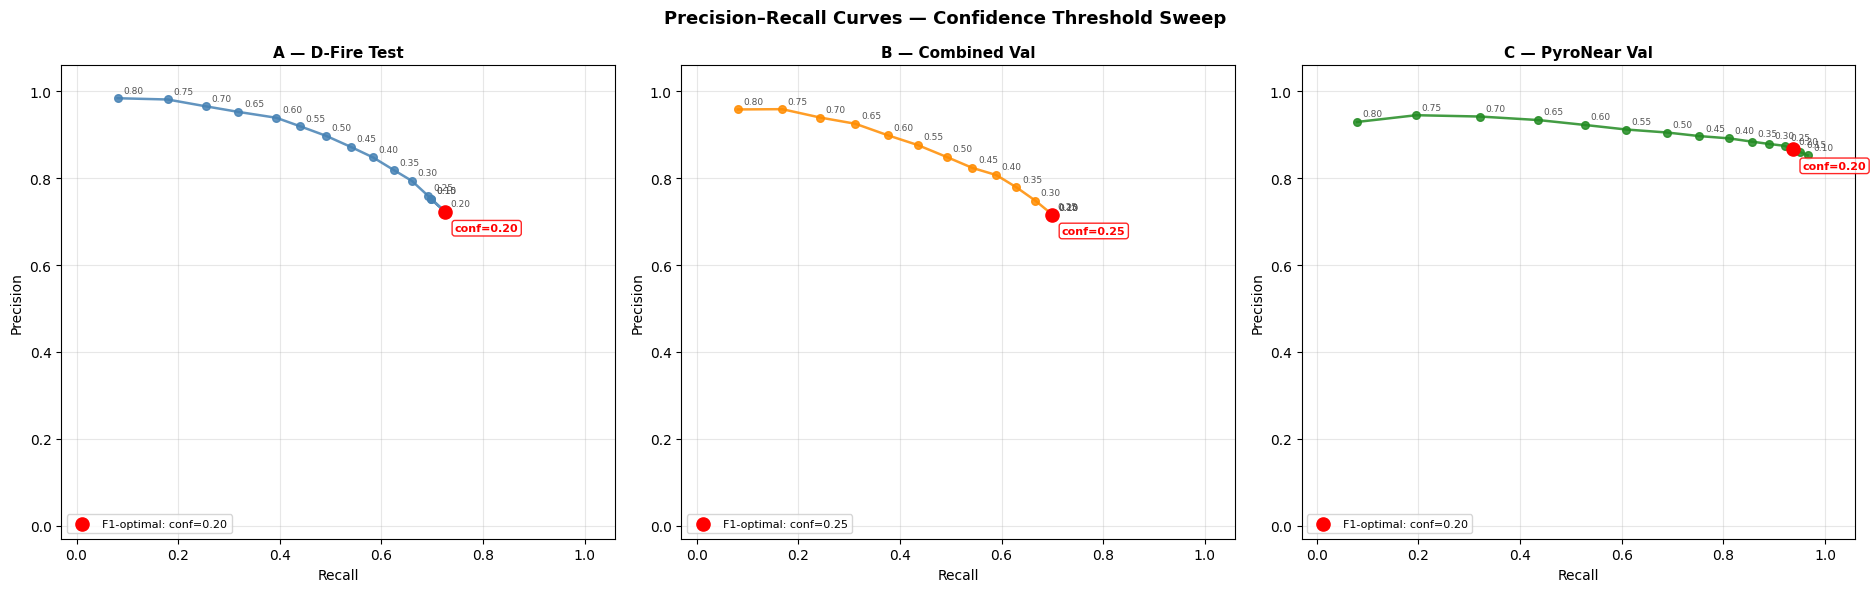

  Saved: pr_curve_dfire.png
  Saved: pr_curve_combined.png
  Saved: pr_curve_pyronear.png
All PR curves saved ✅


In [25]:
EVAL_SETS = [
    ("recall_dfire",    "prec_dfire",    "A — D-Fire Test",  "steelblue",   "pr_curve_dfire.png"),
    ("recall_combined", "prec_combined", "B — Combined Val", "darkorange",  "pr_curve_combined.png"),
    ("recall_pyronear", "prec_pyronear", "C — PyroNear Val", "forestgreen", "pr_curve_pyronear.png"),
]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle("Precision–Recall Curves — Confidence Threshold Sweep",
             fontsize=13, fontweight="bold")

for ax, (rec_col, prec_col, title, color, fname) in zip(axes, EVAL_SETS):
    recs  = df[rec_col].values
    precs = df[prec_col].values
    confs = df["conf"].values
    # F1-optimal point: closest to (Recall=1, Precision=1)
    best  = int(np.argmin(np.hypot(1 - recs, 1 - precs)))

    ax.plot(recs, precs, "o-", color=color, lw=1.8, ms=5.5, alpha=0.85, zorder=3)
    for r, p, conf in zip(recs, precs, confs):
        ax.annotate(f"{conf:.2f}", (r, p), textcoords="offset points",
                    xytext=(4, 4), fontsize=6.5, color="#555")
    ax.scatter([recs[best]], [precs[best]], color="red", s=90, zorder=5,
               label=f"F1-optimal: conf={confs[best]:.2f}")
    ax.annotate(f"conf={confs[best]:.2f}", (recs[best], precs[best]),
                textcoords="offset points", xytext=(7, -14), fontsize=8,
                color="red", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="red", alpha=0.85))
    ax.set_xlabel("Recall", fontsize=10)
    ax.set_ylabel("Precision", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlim(-0.03, 1.06); ax.set_ylim(-0.03, 1.06)
    ax.legend(fontsize=8, loc="lower left")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pr_curves_all.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Individual PR curves ──────────────────────────────────────────────────────
for rec_col, prec_col, title, color, fname in EVAL_SETS:
    recs  = df[rec_col].values
    precs = df[prec_col].values
    confs = df["conf"].values
    best  = int(np.argmin(np.hypot(1 - recs, 1 - precs)))
    fig_s, ax_s = plt.subplots(figsize=(7, 6))
    ax_s.plot(recs, precs, "o-", color=color, lw=1.8, ms=5.5, alpha=0.85)
    for r, p, conf in zip(recs, precs, confs):
        ax_s.annotate(f"{conf:.2f}", (r, p), textcoords="offset points",
                      xytext=(4, 4), fontsize=7, color="#555")
    ax_s.scatter([recs[best]], [precs[best]], color="red", s=90, zorder=5,
                 label=f"F1-optimal: conf={confs[best]:.2f}")
    ax_s.set_xlabel("Recall"); ax_s.set_ylabel("Precision")
    ax_s.set_title(f"PR Curve — {title}", fontweight="bold")
    ax_s.set_xlim(-0.03, 1.06); ax_s.set_ylim(-0.03, 1.06)
    ax_s.legend(fontsize=8, loc="lower left")
    ax_s.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{fname}", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  Saved: {fname}")

print("All PR curves saved ✅")


### 16b. FP Rate vs Recall Tradeoff (PyroNear)

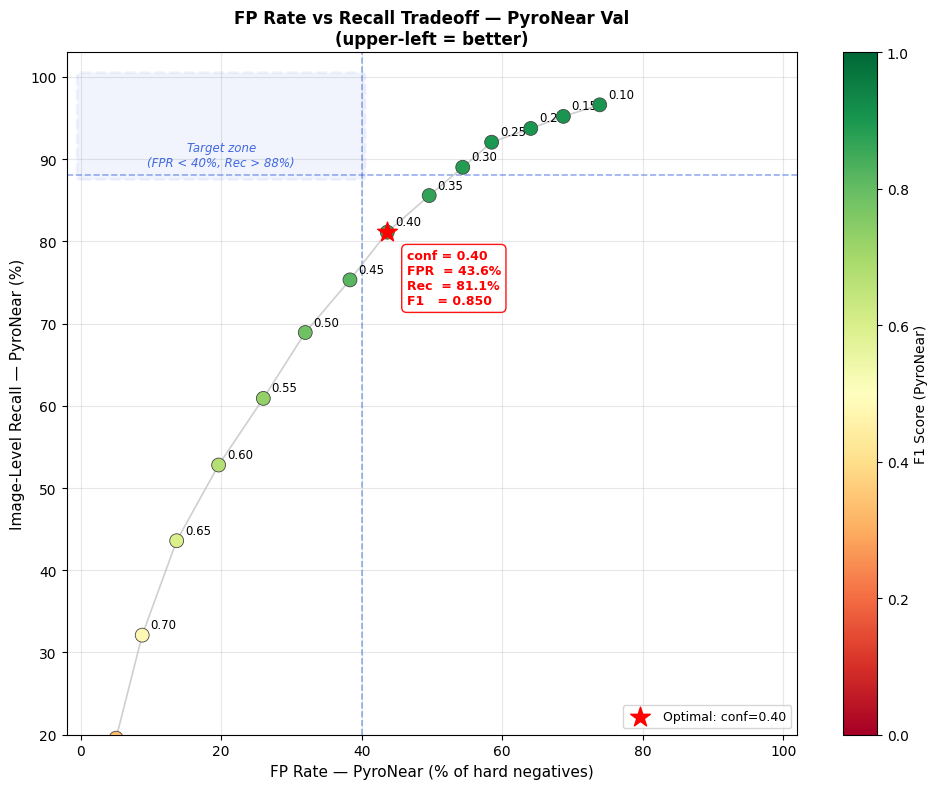

Note: No threshold in target zone — best compromise shown
Saved: fp_recall_tradeoff_pyronear.png ✅


In [26]:
TARGET_FPR_MAX = 40.0   # % — upper bound on acceptable FP rate
TARGET_REC_MIN = 88.0   # % — lower bound on acceptable recall

fp_pct  = df["fp_rate_pyronear"].values * 100
rec_pct = df["recall_pyronear"].values  * 100
f1s     = df["f1_pyronear"].values
confs   = df["conf"].values

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(fp_pct, rec_pct, c=f1s, cmap="RdYlGn", s=100, zorder=5,
                vmin=0, vmax=1, edgecolors="#444", linewidths=0.6)
ax.plot(fp_pct, rec_pct, "-", color="#bbb", lw=1.2, alpha=0.7, zorder=3)
plt.colorbar(sc, ax=ax, label="F1 Score (PyroNear)")

for fpr, rec, conf in zip(fp_pct, rec_pct, confs):
    ax.annotate(f"{conf:.2f}", (fpr, rec), textcoords="offset points",
                xytext=(6, 5), fontsize=8.5)

# Target zone rectangle
ax.add_patch(patches.FancyBboxPatch(
    (0, TARGET_REC_MIN), TARGET_FPR_MAX, 100 - TARGET_REC_MIN,
    boxstyle="round,pad=0.5", lw=2, edgecolor="royalblue",
    facecolor="royalblue", alpha=0.07, linestyle="--", zorder=2))
ax.axvline(x=TARGET_FPR_MAX, color="royalblue", ls="--", lw=1.2, alpha=0.55)
ax.axhline(y=TARGET_REC_MIN, color="royalblue", ls="--", lw=1.2, alpha=0.55)
ax.text(TARGET_FPR_MAX / 2, TARGET_REC_MIN + 0.8,
        f"Target zone\n(FPR < {TARGET_FPR_MAX:.0f}%, Rec > {TARGET_REC_MIN:.0f}%)",
        ha="center", va="bottom", fontsize=8.5,
        color="royalblue", fontstyle="italic")

# Optimal operating point
in_zone = df[(df.fp_rate_pyronear * 100 < TARGET_FPR_MAX) &
             (df.recall_pyronear  * 100 > TARGET_REC_MIN)]

if len(in_zone) > 0:
    opt_row  = in_zone.loc[in_zone.f1_pyronear.idxmax()]
    opt_note = f"Best F1 in target zone ({len(in_zone)} candidate(s))"
else:
    opt_row  = df.loc[(df.fp_rate_pyronear - df.recall_pyronear).idxmin()]
    opt_note = "No threshold in target zone — best compromise shown"

opt_fpr = float(opt_row.fp_rate_pyronear) * 100
opt_rec = float(opt_row.recall_pyronear)  * 100

ax.scatter([opt_fpr], [opt_rec], color="red", s=220, zorder=6, marker="*",
           label=f"Optimal: conf={opt_row.conf:.2f}")
ax.annotate(
    f"conf = {opt_row.conf:.2f}\nFPR  = {opt_fpr:.1f}%\nRec  = {opt_rec:.1f}%\nF1   = {float(opt_row.f1_pyronear):.3f}",
    (opt_fpr, opt_rec), textcoords="offset points", xytext=(14, -52),
    fontsize=9, color="red", fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="red", alpha=0.92))

ax.set_xlabel("FP Rate — PyroNear (% of hard negatives)", fontsize=11)
ax.set_ylabel("Image-Level Recall — PyroNear (%)", fontsize=11)
ax.set_title("FP Rate vs Recall Tradeoff — PyroNear Val\n(upper-left = better)",
             fontsize=12, fontweight="bold")
ax.set_xlim(-2, 102); ax.set_ylim(20, 103)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fp_recall_tradeoff_pyronear.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Note: {opt_note}")
print(f"Saved: fp_recall_tradeoff_pyronear.png ✅")


---
## 17. Spatial Prior Analysis (Extension)

**Goal:** Determine whether false alarms cluster in specific image regions  
(e.g. upper sky zone in PyroNear tower-camera images). If so, a spatial mask  
can suppress FPs *without* raising the confidence threshold or retraining.

This section is independent of the main sweep and can be skipped if not needed.

Steps:
1. Collect box centre positions at mining conf (0.10) for TP and FP images
2. Visualise heatmaps of FP vs TP box centres
3. Quantify sky-zone concentration across multiple Y thresholds
4. Apply the best spatial filter and re-sweep thresholds
5. Compare original vs filtered tradeoff curve
6. Print best operating point after filtering


In [27]:
MINING_CONF   = 0.10  # low conf for spatial mining — captures uncertain detections

# ── Separate PyroNear images by ground-truth class ────────────────────────────
pyro_neg_set = {
    str(p) for p, l in zip(pyro_val_imgs, pyro_val_lbls)
    if l.exists() and not l.read_text().strip()
}
pyro_pos_set = {
    str(p) for p, l in zip(pyro_val_imgs, pyro_val_lbls)
    if l.exists() and l.read_text().strip()
}

# ── Collect box centre positions ──────────────────────────────────────────────
fp_box_centers = []
tp_box_centers = []
all_pyro       = [str(p) for p in pyro_val_imgs]
CACHE_BATCH    = 64

print("Collecting box positions from PyroNear val images ...")
for i in range(0, len(all_pyro), CACHE_BATCH):
    chunk = all_pyro[i : i + CACHE_BATCH]
    preds = eval_model.predict(source=chunk, imgsz=640, conf=MINING_CONF,
                               iou=IOU_THRESHOLD, device=0, verbose=False)
    for pred, img_path in zip(preds, chunk):
        if len(pred.boxes) == 0:
            continue
        boxes_norm = pred.boxes.xywhn.cpu().numpy()  # (N, 4): cx, cy, w, h
        for box in boxes_norm:
            cx, cy = float(box[0]), float(box[1])
            if img_path in pyro_neg_set:
                fp_box_centers.append((cx, cy))
            elif img_path in pyro_pos_set:
                tp_box_centers.append((cx, cy))
    done = min(i + CACHE_BATCH, len(all_pyro))
    if done % 500 < CACHE_BATCH or done == len(all_pyro):
        print(f"  {done:>5} / {len(all_pyro)}")

fp_centers = np.array(fp_box_centers) if fp_box_centers else np.zeros((0, 2))
tp_centers = np.array(tp_box_centers) if tp_box_centers else np.zeros((0, 2))
print(f"\nFP detections collected : {len(fp_centers)}")
print(f"TP detections collected : {len(tp_centers)}")


    512 / 4099
   1024 / 4099
   1536 / 4099
   2048 / 4099
   2560 / 4099
   3008 / 4099
   3520 / 4099
   4032 / 4099
   4099 / 4099

FP detections collected : 753
TP detections collected : 5066


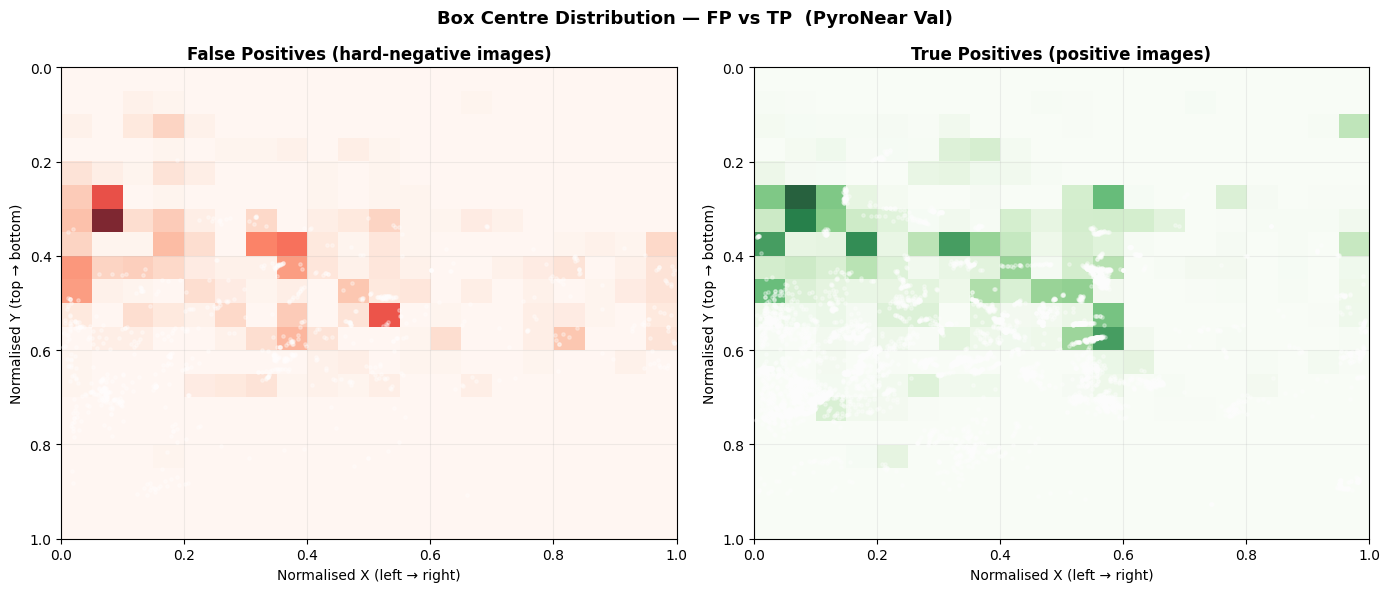

Saved: spatial_distribution_fp_vs_tp.png ✅


In [28]:
# ── Step 2: Spatial heatmap ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Box Centre Distribution — FP vs TP  (PyroNear Val)",
             fontsize=13, fontweight="bold")

for ax, centers, label, cmap in [
    (axes[0], fp_centers, "False Positives (hard-negative images)", "Reds"),
    (axes[1], tp_centers, "True Positives (positive images)",       "Greens"),
]:
    if len(centers) > 1:
        heatmap, xedges, yedges = np.histogram2d(
            centers[:, 0], centers[:, 1],
            bins=20, range=[[0, 1], [0, 1]]
        )
        ax.imshow(heatmap.T, origin="upper", extent=[0, 1, 0, 1],
                  cmap=cmap, aspect="auto", alpha=0.85)
    if len(centers) > 0:
        ax.scatter(centers[:, 0], centers[:, 1],
                   s=6, alpha=0.3, color="white", zorder=3)
    ax.set_xlabel("Normalised X (left → right)")
    ax.set_ylabel("Normalised Y (top → bottom)")
    ax.set_title(label, fontweight="bold")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.invert_yaxis()   # image convention: y=0 at top
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/spatial_distribution_fp_vs_tp.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: spatial_distribution_fp_vs_tp.png ✅")


In [29]:
# ── Step 3: Sky-zone concentration analysis ───────────────────────────────────
SKY_ZONE_THRESHOLDS = [0.20, 0.30, 0.40, 0.50]

print("── Sky Zone Analysis ──────────────────────────────────────────────────────")
print(f"{'Sky zone (top %)':>18} | {'FP in zone':>10} {'FP%':>6} | "
      f"{'TP in zone':>10} {'TP%':>6} | {'Ratio':>6}")
print("-" * 70)

best_sky_thresh = SKY_ZONE_THRESHOLDS[0]
best_score      = -float("inf")

for sky_thresh in SKY_ZONE_THRESHOLDS:
    fp_in_sky = int((fp_centers[:, 1] < sky_thresh).sum()) if len(fp_centers) else 0
    tp_in_sky = int((tp_centers[:, 1] < sky_thresh).sum()) if len(tp_centers) else 0
    fp_pct_sky = fp_in_sky / len(fp_centers) * 100 if len(fp_centers) else 0.0
    tp_pct_sky = tp_in_sky / len(tp_centers) * 100 if len(tp_centers) else 0.0
    ratio      = fp_pct_sky / tp_pct_sky if tp_pct_sky > 0 else float("inf")
    print(f"  top {sky_thresh*100:>4.0f}%          | {fp_in_sky:>10} {fp_pct_sky:>5.1f}% | "
          f"{tp_in_sky:>10} {tp_pct_sky:>5.1f}% | {ratio:>5.2f}x")
    # Best = maximise FP suppression relative to TP loss
    score = fp_pct_sky - tp_pct_sky
    if score > best_score:
        best_score      = score
        best_sky_thresh = sky_thresh

print(f"\nAuto-selected sky threshold : top {best_sky_thresh*100:.0f}% of image")
SKY_FILTER_Y = best_sky_thresh


── Sky Zone Analysis ──────────────────────────────────────────────────────
  Sky zone (top %) | FP in zone    FP% | TP in zone    TP% |  Ratio
----------------------------------------------------------------------
  top   20%          |          1   0.1% |         34   0.7% |  0.20x
  top   30%          |          1   0.1% |         99   2.0% |  0.07x
  top   40%          |         39   5.2% |        301   5.9% |  0.87x
  top   50%          |        206  27.4% |       1038  20.5% |  1.34x

Auto-selected sky threshold : top 50% of image


In [30]:
# ── Step 4: Build spatially-filtered cache ────────────────────────────────────
def apply_spatial_filter(pred, sky_y=SKY_FILTER_Y):
    """
    Remove detections whose box centre falls in the sky zone (cy < sky_y).
    Returns filtered confidence list — compatible with cache structure.
    """
    if len(pred.boxes) == 0:
        return []
    boxes_norm = pred.boxes.xywhn.cpu().numpy()   # (N, 4): cx, cy, w, h
    confs      = pred.boxes.conf.cpu().numpy()
    return [
        float(c)
        for box, c in zip(boxes_norm, confs)
        if box[1] >= sky_y   # cy >= threshold → not sky zone → keep
    ]


print(f"Building spatially-filtered cache  (sky zone = top {SKY_FILTER_Y*100:.0f}%) ...")
cache_pyro_filtered = {}

for i in range(0, len(all_pyro), CACHE_BATCH):
    chunk = all_pyro[i : i + CACHE_BATCH]
    preds = eval_model.predict(source=chunk, imgsz=640, conf=MINING_CONF,
                               iou=IOU_THRESHOLD, device=0, verbose=False)
    for pred, img_path in zip(preds, chunk):
        key = str(Path(img_path).resolve())
        cache_pyro_filtered[key] = apply_spatial_filter(pred, SKY_FILTER_Y)
    done = min(i + CACHE_BATCH, len(all_pyro))
    if done % 500 < CACHE_BATCH or done == len(all_pyro):
        print(f"  {done:>5} / {len(all_pyro)}")

print("Filtered cache built ✅")


# ── Step 5: Sweep thresholds on filtered cache ────────────────────────────────
# We also need the original cache keyed by resolved path for comparison.
# Rebuild from cache_C (already resolved-key) aliased to cache_pyro for clarity.
cache_pyro = {str(Path(k).resolve()): v for k, v in cache_C.items()}

print("\n── Spatial Filter Impact — Threshold Sweep ──────────────────────────────────")
print(f"{'Conf':>5} | {'Recall (orig)':>13} {'FPR (orig)':>10} | "
      f"{'Recall (filt)':>13} {'FPR (filt)':>10} | "
      f"{'ΔFPR':>7} {'ΔRecall':>8}")
print("-" * 87)

filtered_results = []
for thresh in THRESHOLDS:
    tp_o, fp_o, fn_o = pyronear_from_cache(cache_pyro,          pyro_val_imgs, pyro_lbl_map, thresh)
    tp_f, fp_f, fn_f = pyronear_from_cache(cache_pyro_filtered, pyro_val_imgs, pyro_lbl_map, thresh)

    rec_o = tp_o / PYRO_TOTAL_POS if PYRO_TOTAL_POS else 0.0
    fpr_o = fp_o / PYRO_TOTAL_NEG if PYRO_TOTAL_NEG else 0.0
    rec_f = tp_f / PYRO_TOTAL_POS if PYRO_TOTAL_POS else 0.0
    fpr_f = fp_f / PYRO_TOTAL_NEG if PYRO_TOTAL_NEG else 0.0

    delta_fpr = (fpr_o - fpr_f) * 100
    delta_rec = (rec_f - rec_o) * 100

    filtered_results.append({
        "conf":          thresh,
        "recall_orig":   rec_o,   "fpr_orig":    fpr_o,
        "recall_filt":   rec_f,   "fpr_filt":    fpr_f,
        "delta_fpr":     delta_fpr, "delta_recall": delta_rec,
    })

    print(f"{thresh:>5.2f} | {rec_o*100:>12.1f}% {fpr_o*100:>9.1f}% | "
          f"{rec_f*100:>12.1f}% {fpr_f*100:>9.1f}% | "
          f"{delta_fpr:>+6.1f}pp {delta_rec:>+7.1f}pp")

print("-" * 87)
df_filtered = pd.DataFrame(filtered_results)
csv_f = f"{OUTPUT_DIR}/spatial_filter_sweep.csv"
df_filtered.to_csv(csv_f, index=False)
print(f"\nSaved → {csv_f} ✅")


Building spatially-filtered cache  (sky zone = top 50%) ...
    512 / 4099
   1024 / 4099
   1536 / 4099
   2048 / 4099
   2560 / 4099
   3008 / 4099
   3520 / 4099
   4032 / 4099
   4099 / 4099
Filtered cache built ✅

── Spatial Filter Impact — Threshold Sweep ──────────────────────────────────
 Conf | Recall (orig) FPR (orig) | Recall (filt) FPR (filt) |    ΔFPR  ΔRecall
---------------------------------------------------------------------------------------
 0.10 |         96.6%      73.9% |         74.6%      54.5% |  +19.4pp   -22.0pp
 0.15 |         95.2%      68.7% |         73.8%      50.0% |  +18.7pp   -21.4pp
 0.20 |         93.7%      64.1% |         72.9%      46.9% |  +17.1pp   -20.8pp
 0.25 |         92.0%      58.5% |         71.8%      43.5% |  +15.0pp   -20.2pp
 0.30 |         89.0%      54.4% |         69.7%      41.0% |  +13.4pp   -19.3pp
 0.35 |         85.6%      49.6% |         67.1%      37.5% |  +12.1pp   -18.4pp
 0.40 |         81.1%      43.6% |         64.4%  

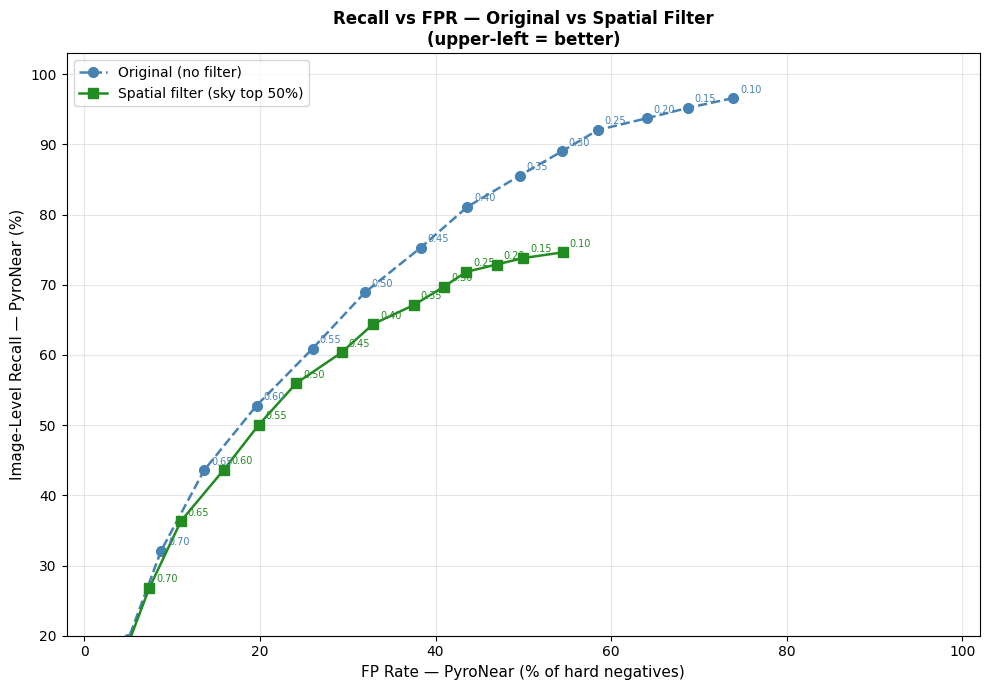

Saved: spatial_filter_tradeoff.png ✅

── Best Operating Point After Spatial Filtering ─────────────────────────
  Conf threshold  : 0.50
  Recall          : 56.0%  (was 68.9%)
  FP Rate         : 24.1%   (was 32.0%)
  FPR reduction   : +7.8 pp
  Recall change   : -12.9 pp
──────────────────────────────────────────────────────────────────────────


In [31]:
# ── Step 6: Visualise original vs filtered tradeoff ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(df_filtered.fpr_orig  * 100, df_filtered.recall_orig  * 100,
        "o--", color="steelblue",   lw=1.8, ms=7, label="Original (no filter)")
ax.plot(df_filtered.fpr_filt  * 100, df_filtered.recall_filt  * 100,
        "s-",  color="forestgreen", lw=1.8, ms=7,
        label=f"Spatial filter (sky top {SKY_FILTER_Y*100:.0f}%)")

for _, row in df_filtered.iterrows():
    ax.annotate(f"{row.conf:.2f}",
                (row.fpr_orig * 100, row.recall_orig * 100),
                textcoords="offset points", xytext=(5, 4), fontsize=7, color="steelblue")
    ax.annotate(f"{row.conf:.2f}",
                (row.fpr_filt * 100, row.recall_filt * 100),
                textcoords="offset points", xytext=(5, 4), fontsize=7, color="forestgreen")

ax.set_xlabel("FP Rate — PyroNear (% of hard negatives)", fontsize=11)
ax.set_ylabel("Image-Level Recall — PyroNear (%)", fontsize=11)
ax.set_title("Recall vs FPR — Original vs Spatial Filter\n(upper-left = better)",
             fontsize=12, fontweight="bold")
ax.set_xlim(-2, 102); ax.set_ylim(20, 103)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/spatial_filter_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: spatial_filter_tradeoff.png ✅")


# ── Step 7: Best operating point after filtering ──────────────────────────────
df_filtered["score"] = df_filtered.recall_filt - df_filtered.fpr_filt
best = df_filtered.loc[df_filtered.score.idxmax()]

print("\n── Best Operating Point After Spatial Filtering ─────────────────────────")
print(f"  Conf threshold  : {best.conf:.2f}")
print(f"  Recall          : {best.recall_filt*100:.1f}%  (was {best.recall_orig*100:.1f}%)")
print(f"  FP Rate         : {best.fpr_filt*100:.1f}%   (was {best.fpr_orig*100:.1f}%)")
print(f"  FPR reduction   : {best.delta_fpr:+.1f} pp")
print(f"  Recall change   : {best.delta_recall:+.1f} pp")
print("──────────────────────────────────────────────────────────────────────────")


---
## 18. Final Summary

All sweep artefacts saved to `/kaggle/working/`:

| File | Contents |
|------|----------|
| `threshold_sweep_results.csv` | Full per-threshold metrics for all three eval sets |
| `pr_curves_all.png` | Combined PR curves (A, B, C) |
| `pr_curve_dfire.png` | Individual D-Fire PR curve |
| `pr_curve_combined.png` | Individual Combined Val PR curve |
| `pr_curve_pyronear.png` | Individual PyroNear PR curve |
| `fp_recall_tradeoff_pyronear.png` | FPR vs Recall scatter with target zone |
| `spatial_distribution_fp_vs_tp.png` | Box centre heatmaps |
| `spatial_filter_sweep.csv` | Per-threshold metrics with/without spatial filter |
| `spatial_filter_tradeoff.png` | Original vs filtered tradeoff comparison |

**Deployment decision checklist:**
- [ ] Pre-sweep Eval C metrics align with training notebook
- [ ] Chosen threshold satisfies domain-specific FPR + recall requirements
- [ ] Sweep results validated on a held-out set not used during training
- [ ] If spatial filter used: confirm it doesn't suppress low-horizon smoke events
